In [2]:
# imports

import os
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import random
from pathlib import Path

In [5]:
# base config

PROJECT_ROOT = Path("..").resolve()

DATA_ROOT = PROJECT_ROOT / "data/raw/messy_mashup"

GENRES_PATH = DATA_ROOT / "genres_stems"

ESC_PATH = DATA_ROOT / "ESC-50-master/audio"

AUGMENT_SAVE = PROJECT_ROOT / "data/interim/augmented_samples"
# assert all paths exist
assert GENRES_PATH.exists(), f"Genres path not found: {GENRES_PATH}"
assert ESC_PATH.exists(), f"ESC-50 path not found: {ESC_PATH}"
assert AUGMENT_SAVE.exists(), f"Augmentation save path not found: {AUGMENT_SAVE}"

In [6]:
# load a sample stem

sample_file = os.path.join(
    GENRES_PATH,
    "jazz",
    "jazz.00000",
    "bass.wav"
)

y, sr = librosa.load(sample_file, sr=22050)

print("Sample rate:", sr)
print("Duration:", len(y)/sr)

/home/saber/IITM/DL-GenAI-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample rate: 22050
Duration: 30.013333333333332


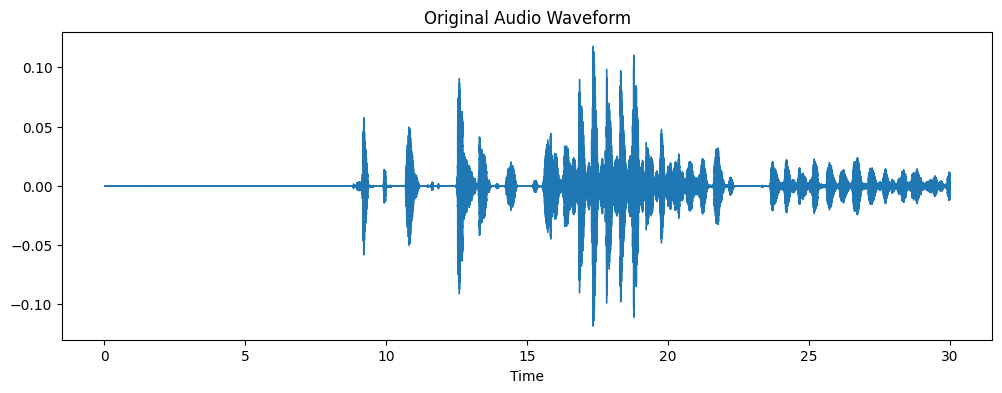

In [7]:
# plot origina waveform

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Original Audio Waveform")
plt.show()

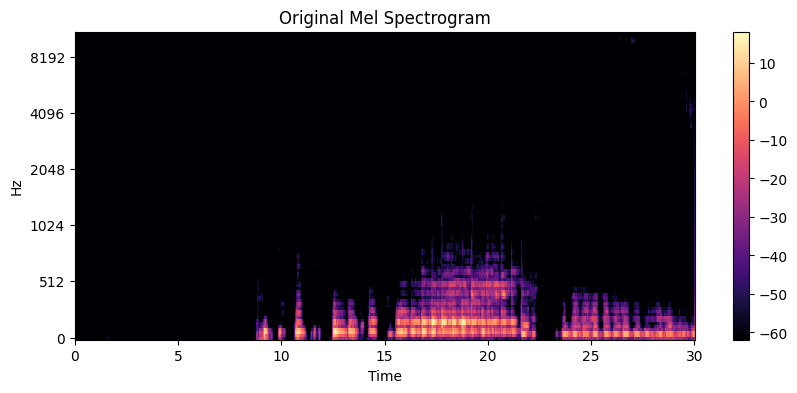

In [9]:
# plot original spectrogram

mel = librosa.feature.melspectrogram(y=y, sr=sr)
mel_db = librosa.power_to_db(mel)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    x_axis="time",
    y_axis="mel",
    sr=sr
)

plt.colorbar()
plt.title("Original Mel Spectrogram")

plt.show()

In [16]:
# augmentation functions

def pitch_shift(y, sr, steps=2):
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)

def time_stretch(y, rate=1.2):
    return librosa.effects.time_stretch(y=y, rate=rate)

def add_noise(y, noise_factor=0.02):
    noise = np.random.randn(len(y))
    return y + noise_factor * noise

def volume_scale(y, gain=1.5):
    return y * gain

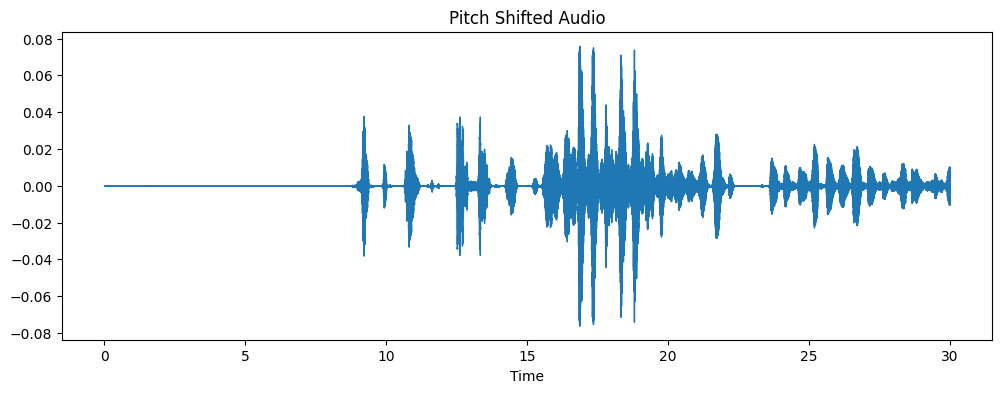

In [22]:
# pitch shift visualization

y_pitch = pitch_shift(y, sr, steps=3)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y_pitch, sr=sr)
plt.title("Pitch Shifted Audio")
plt.show()

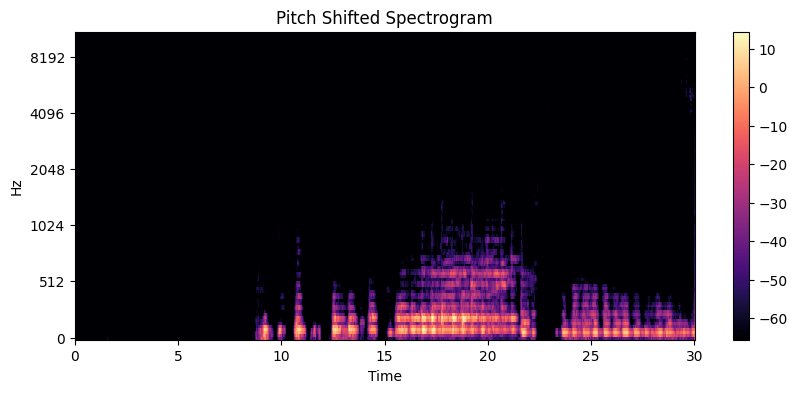

In [13]:
# pitch shift spectrogram visualization

mel = librosa.feature.melspectrogram(y=y_pitch, sr=sr)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    librosa.power_to_db(mel),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Pitch Shifted Spectrogram")

plt.show()

In [14]:
# save sample
sf.write(os.path.join(AUGMENT_SAVE,"pitch_shift.wav"), y_pitch, sr)

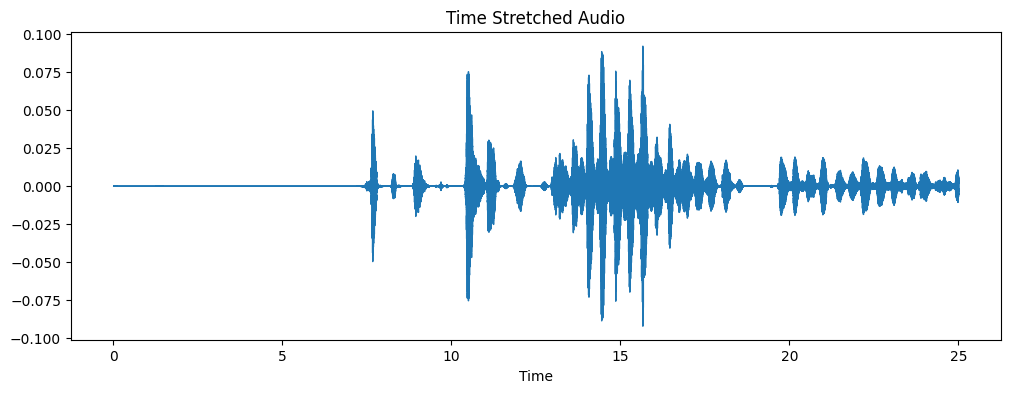

In [17]:
# time stretch visualization
y_stretch = time_stretch(y, rate=1.2)

plt.figure(figsize=(12,4))
librosa.display.waveshow(y_stretch, sr=sr)

plt.title("Time Stretched Audio")

plt.show()

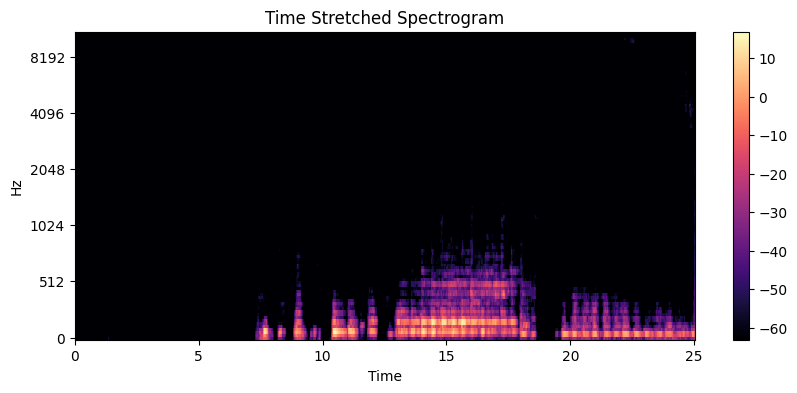

In [21]:
# time stretched spectrogram visualization

mel = librosa.feature.melspectrogram(y=y_stretch, sr=sr)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    librosa.power_to_db(mel),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Time Stretched Spectrogram")

plt.show()

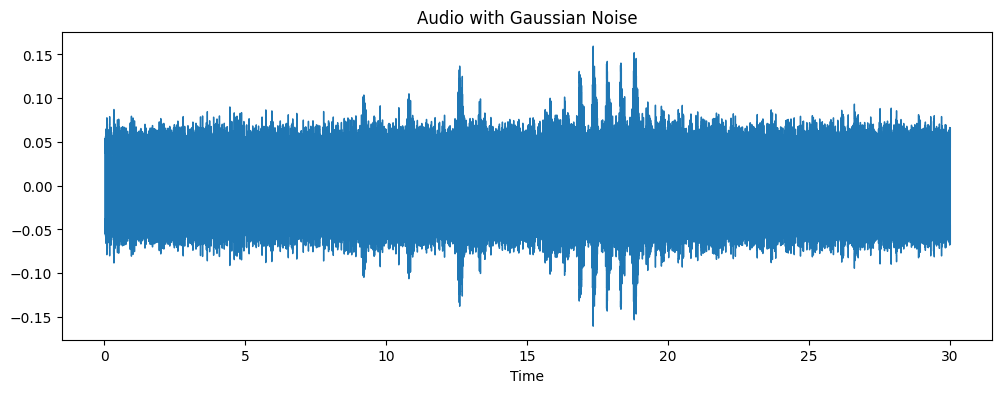

In [23]:
# random noise injection visualization

y_noise = add_noise(y)

plt.figure(figsize=(12,4))

librosa.display.waveshow(y_noise, sr=sr)

plt.title("Audio with Gaussian Noise")

plt.show()

In [25]:
# environmental noise mixing

esc_files = os.listdir(ESC_PATH)

noise_file = os.path.join(ESC_PATH, random.choice(esc_files))

noise, sr_noise = librosa.load(noise_file, sr=22050)

# repeat noise until long enough
if len(noise) < len(y):
    repeats = int(np.ceil(len(y) / len(noise)))
    noise = np.tile(noise, repeats)

# trim to exact length
noise = noise[:len(y)]

# mix
y_mix = y + 0.3 * noise

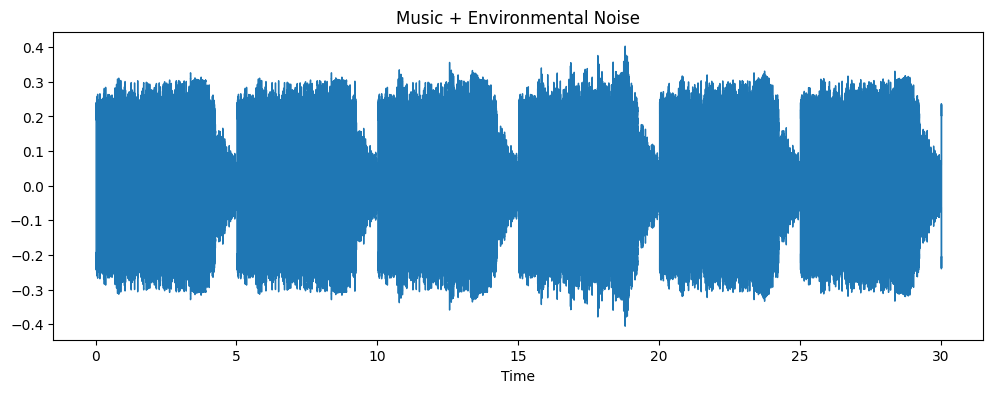

In [26]:
plt.figure(figsize=(12,4))

librosa.display.waveshow(y_mix, sr=sr)

plt.title("Music + Environmental Noise")

plt.show()

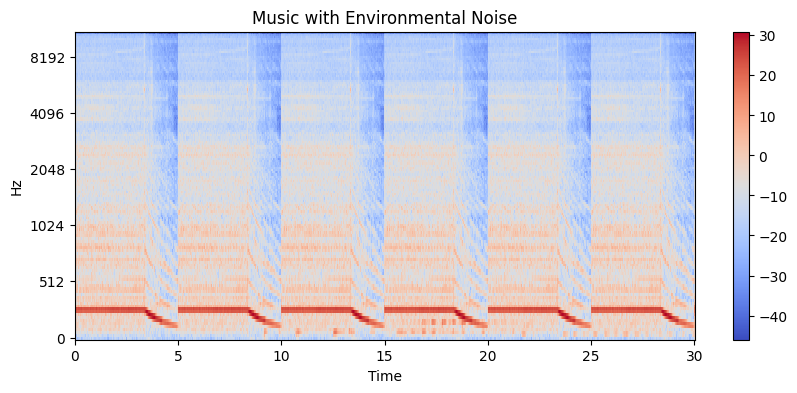

In [27]:
# spectorgram with noise visualization

mel = librosa.feature.melspectrogram(y=y_mix, sr=sr)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    librosa.power_to_db(mel),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("Music with Environmental Noise")

plt.show()

In [28]:
# save augmented audio

sf.write(os.path.join(AUGMENT_SAVE,"esc50_mix.wav"), y_mix, sr)

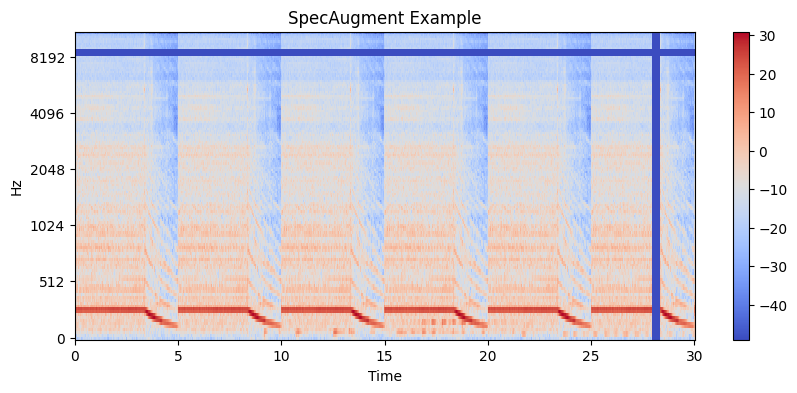

In [30]:
# spectorgram augmented

def spec_augment(mel, freq_mask=15, time_mask=30):

    mel_aug = mel.copy()

    # frequency mask
    f = np.random.randint(0, freq_mask)
    f0 = random.randint(0, mel.shape[0] - f)

    mel_aug[f0:f0+f,:] = 0

    # time mask
    t = np.random.randint(0, time_mask)
    t0 = random.randint(0, mel.shape[1] - t)

    mel_aug[:,t0:t0+t] = 0

    return mel_aug

mel_aug = spec_augment(mel)

plt.figure(figsize=(10,4))

librosa.display.specshow(
    librosa.power_to_db(mel_aug),
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar()

plt.title("SpecAugment Example")

plt.show()